# zalesak_disk

Error norms and boundedness over ten rotations, then a two-panel animation
of the disk under the $\phi$-normal and the $\psi$-normal.

The exact solution is the **rotated** initial shape -- the flow is a rigid
rotation at $\omega=\pi$, so `norms.slotted_disk_phase_at` evaluates the
initial field at the pre-image of each point. Comparing against the
unrotated disk is only correct at whole rotations and gives $E_r = 1.24$
instead of 0.0066 at $t=0.2$.


In [1]:
import glob, os, sys, logging
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.tri as mtri
from matplotlib.animation import FuncAnimation, FFMpegWriter
from mpi4py import MPI
from pysemtools.io.ppymech.neksuite import preadnek
from pysemtools.datatypes.msh import Mesh as msh_c
from pysemtools.datatypes.field import Field as field_c
from pysemtools.datatypes.coef import Coef

sys.path.insert(0, os.path.abspath(".."))   # examples/norms.py
import norms as nm

logging.disable(logging.INFO)
comm = MPI.COMM_WORLD

FPS = 10        # 25 fps ran a full traversal/rotation in under a second
EPS = 0.0112          # xi = eps*N/H = 2.8

RUNS = [("zalesak",                r"$\psi$-normal (primary)"),
        ("zalesak_phi_normal",     r"$\phi$-normal baseline"),
        ("zalesak_redistance_phi", r"+ redistancing, seed=phi"),
        ("zalesak_redistance_psi", r"+ redistancing, seed=psi")]

## Error and boundedness

`worst viol` is $\max(\phi-1,\,-\phi,\,0)$ over **every** frame, not the
last: a run can violate transiently and recover. Boundedness is the
property this method is really judged on, so it gets its own columns.


In [2]:
msh = coef = per = None
print(f"{'run':<26} {'t_end':>7} {'E_r':>9} {'E_v':>11} {'E_s':>9} "
      f"{'worst viol':>11} {'worst n':>8}")
for tag, label in RUNS:
    f = sorted(glob.glob(f"output_{tag}/field0.f?????"))
    if not f:
        print(f"{tag:<26}   (no output)"); continue
    if msh is None:
        msh = msh_c(comm, data=preadnek(f[0], comm)); coef = Coef(msh, comm)
        per = nm.contour_length(msh, nm.slotted_disk_phase(msh.x, msh.y, EPS), 0.5)
    worst_v, worst_n = 0.0, 0
    for ff in f:
        p = field_c(comm, data=preadnek(ff, comm)).fields["temp"][0]
        worst_v = max(worst_v, max(p.max()-1.0, -p.min(), 0.0))
        worst_n = max(worst_n, nm.n_unbounded(p))
    phi0 = field_c(comm, data=preadnek(f[0], comm)).fields["temp"][0]
    o = field_c(comm, data=preadnek(f[-1], comm)); phi = o.fields["temp"][0]
    pe = nm.slotted_disk_phase_at(msh.x, msh.y, o.t, EPS)
    print(f"{tag:<26} {o.t:>7.2f} {nm.E_r(phi,pe,coef,msh):>9.5f} "
          f"{nm.E_v(phi,phi0,pe,coef,msh):>11.2e} {nm.E_s(phi,pe,coef,msh,per):>9.5f} "
          f"{worst_v:>11.2e} {worst_n:>8d}")

# t = 0 self-check against the exact initial condition
f0 = sorted(glob.glob('output_zalesak/field0.f?????'))[0]
p0 = field_c(comm, data=preadnek(f0, comm)).fields['temp'][0]
print(f"\nt=0 self-check  E_r = "
      f"{nm.E_r(p0, nm.slotted_disk_phase(msh.x, msh.y, EPS), coef, msh):.2e}"
      "   (must be 0)")

run                          t_end       E_r         E_v       E_s  worst viol  worst n


zalesak                      20.00   0.02204   -4.28e-08   0.00460    0.00e+00        0


zalesak_phi_normal           20.00   1.07383   -2.54e-06   0.29621    6.25e-03    54980


zalesak_redistance_phi       20.00   0.70866   -6.96e-07   0.19693    1.06e-01    49476


zalesak_redistance_psi        3.20   1.68827    4.15e-06   0.34914    0.00e+00        0

t=0 self-check  E_r = 2.00e-07   (must be 0)


## The disk rotating: a one-change-at-a-time ablation

Each panel differs from the $\xi$=2.8, $\gamma$=1, SVV-on reference
(top right) in exactly **one** setting. That configuration is the
common comparison point, not a recommendation.

Unlike `../rider_kothe`, this flow is a rigid rotation, so the exact solution
is known at **every** instant — the initial shape carried round,
`norms.slotted_disk_phase_at`. $E_r$ per frame is therefore meaningful here.

The colour scale runs past $[0,1]$: cyan is $\phi<0$, green $\phi>1$, so a
boundedness violation is unmissable.


In [3]:
PANELS = [("output_zalesak_phi_normal", r"$\phi$-normal  ($\xi$=2.8, SVV on)"),
          ("output_zalesak",            r"$\psi$-normal  ($\xi$=2.8, SVV on)  — reference"),
          ("output_zalesak_nosvv",       r"$\psi$-normal, SVV OFF  ($\xi$=2.8)"),
          ("output_zalesak_xi15",        r"$\psi$-normal, $\xi$=1.5 (SVV on)")]
EPSOF  = {"output_zalesak_phi_normal": 0.0112, "output_zalesak": 0.0112,
          "output_zalesak_nosvv": 0.0112, "output_zalesak_xi15": 0.006}
PANELS = [p for p in PANELS if glob.glob(os.path.join(p[0], "field0.f?????"))]

tri = iz = None
def load(d, want=None):
    global tri, iz
    eps = EPSOF[os.path.basename(d)]        # each run has its own epsilon
    files = sorted(glob.glob(os.path.join(d, "field0.f?????")))
    if tri is None:
        iz = msh.z.shape[1] // 2
        tri = mtri.Triangulation(msh.x[:, iz, :, :].ravel(), msh.y[:, iz, :, :].ravel())
    ts, vals, ers = [], [], []
    for f in files:
        o = field_c(comm, data=preadnek(f, comm)); phi = o.fields["temp"][0]
        if want is not None and not np.any(np.abs(np.array(want) - o.t) < 1e-6):
            continue
        ts.append(o.t); vals.append(phi[:, iz, :, :].ravel())
        ers.append(nm.E_r(phi, nm.slotted_disk_phase_at(msh.x, msh.y, o.t, eps), coef, msh))
    return (np.array(ts), np.array(vals), np.array(ers),
            np.array([[v.min(), v.max()] for v in vals]))

# runs were written at different output intervals, so match on TIME not index
def times(d):
    return [field_c(comm, data=preadnek(f, comm)).t
            for f in sorted(glob.glob(os.path.join(d, "field0.f?????")))]
common = sorted(set.intersection(*[set(np.round(times(d), 6)) for d, _ in PANELS]))
print(f"{len(common)} shared frame times, t = {common[0]:.2f} .. {common[-1]:.2f}")
runs = []
for d, label in PANELS:
    runs.append((label,) + load(d, common))
    print(f"  {label:44s} {len(runs[-1][1])} frames")
nf = min(len(r[1]) for r in runs)

101 shared frame times, t = 0.00 .. 20.00


  $\phi$-normal  ($\xi$=2.8, SVV on)           101 frames


  $\psi$-normal  ($\xi$=2.8, SVV on)  — reference 101 frames


  $\psi$-normal, SVV OFF  ($\xi$=2.8)          101 frames


  $\psi$-normal, $\xi$=1.5 (SVV on)            101 frames


In [4]:
CM = plt.cm.magma.copy(); CM.set_under("#00d4ff"); CM.set_over("#39ff14")
nrow = 2 if len(runs) > 2 else 1
ncol = int(np.ceil(len(runs)/nrow))
fig, axg = plt.subplots(nrow, ncol, figsize=(5.2*ncol, 5.4*nrow), squeeze=False)
axes = axg.ravel()[:len(runs)]
meshes, notes = [], []
for ax, (label, ts, vals, ers, rng) in zip(axes, runs):
    tp = ax.tripcolor(tri, vals[0], shading="gouraud", cmap=CM, vmin=0.0, vmax=1.0)
    ax.set_aspect("equal"); ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    ax.set_title(label, fontsize=10); ax.set_xlabel("x"); ax.set_ylabel("y")
    notes.append(ax.text(0.03, 0.03, "", transform=ax.transAxes, fontsize=8,
                         family="monospace", va="bottom",
                         bbox=dict(fc="white", ec="0.8", alpha=0.9, pad=2.5)))
    meshes.append(tp)
for ax in axg.ravel()[len(runs):]:
    ax.axis("off")
fig.colorbar(meshes[-1], ax=list(axg.ravel()), fraction=0.025, pad=0.02,
             label=r"$\phi$", extend="both")
sup = fig.suptitle("")

def frame(i):
    t = runs[0][1][i]
    for k, (label, ts, vals, ers, rng) in enumerate(runs):
        meshes[k].set_array(vals[i])
        notes[k].set_text(f"$E_r$ = {ers[i]:7.4f}\n"
                          f"$\\phi\\in$[{rng[i,0]:+.3f}, {rng[i,1]:+.3f}]")
    sup.set_text(f"Zalesak disk, t = {t:5.2f}   ({t/2:.2f} of 10 rotations)\n"
                 "exact solution known at every instant (rigid rotation);  "
                 r"cyan $\phi<0$, green $\phi>1$")
    return meshes + notes + [sup]

os.makedirs("evidence", exist_ok=True)
out = "evidence/zalesak_methods.mp4"
FuncAnimation(fig, frame, frames=nf, blit=False).save(
    out, writer=FFMpegWriter(fps=FPS, bitrate=3600))
plt.close(fig)
print("wrote", out, f"({nf} frames, {len(runs)} panels)")

wrote evidence/zalesak_methods.mp4 (101 frames, 4 panels)


In [5]:
from IPython.display import Video
Video("evidence/zalesak_methods.mp4", embed=False, width=920)

## The $(\xi, \gamma)$ map, SVV on

One rotation ($t=2$) at $N=7$ on the same $50^2$ mesh, over
$\xi \in \{0.5, 1, 1.5, 2, 2.8\}$ and $\gamma \in \{0.25, 0.5, 1, 2\}$ with
$\text{svv}_\psi.c_0 = 1.0$ throughout ($\text{svv}_\phi$ is 0 everywhere, as
always in this repo). Every cell is `zalesak_p7.case` with only $\varepsilon$,
$\gamma$, $\Delta t$ and the output cadence changed.

$\Delta t$ obeys **two** limits, not one: the CDI compression CFL
$\gamma u_{\max}\Delta t/h_{\rm GLL,min} \le 0.05$, and — because SVV on $\psi$
is explicit here — $\Delta t\,\rho(B^{-1}S_{vv}) \le 0.4$ with
$\rho = 4089.607$ fixed across the grid. Below $\gamma \approx 0.27$ the SVV
limit is the tighter of the two, which is why the $\gamma=0.25$ row runs at
$\Delta t = 8.8\times10^{-5}$ rather than the $1.04\times10^{-4}$ the
compression CFL alone would allow.

Boundedness is read from the solver's own stdout log (`bnd.txt`, written every
200 steps), not from the frames: at 62 MB a frame, writing often enough to
catch a transient violation would cost hundreds of GB and would still only
*sample* it. `worst` is $\max(\phi-1,\,-\phi,\,0)$ over **every logged step**;
`w/o s1` excludes step 1, which carries a startup transient the frames never
see.

In [6]:
from matplotlib.colors import LogNorm

SW_XI = {"x05": 0.5, "x10": 1.0, "x15": 1.5, "x20": 2.0, "x28": 2.8}
SW_GA = {"g025": 0.25, "g050": 0.5, "g100": 1.0, "g200": 2.0}
DX_GLL = 0.02 / 7          # H/N at N = 7; each cell has its own eps = xi*dx


def read_bnd(path):
    """min/max phi and mass drift per logged step, from the solver's stdout."""
    rows = []
    for line in open(path):
        f = line.split()
        if not f or f[0] != "bnd":
            continue
        try:
            rows.append((int(f[1]), float(f[3]), float(f[4]),
                         float(f[5]), float(f[6])))
        except ValueError:      # NaN/**** from a cell on its way out
            continue
    return np.array(rows, dtype=float)


msh7 = coef7 = None            # N=7: not the same GLL grid as msh/coef above
sweep = []
for d in sorted(glob.glob("output_sw_*")):
    cell = d[len("output_sw_"):]
    xtag, gtag = cell.split("_")
    xi, gamma = SW_XI[xtag], SW_GA[gtag]
    eps = xi * DX_GLL
    diverged = "Normal end." not in open(f"run_sw_{cell}.log").read()[-4000:]

    f = sorted(glob.glob(os.path.join(d, "field0.f?????")))
    if msh7 is None:
        msh7 = msh_c(comm, data=preadnek(f[0], comm)); coef7 = Coef(msh7, comm)

    o0 = field_c(comm, data=preadnek(f[0], comm)); phi0 = o0.fields["temp"][0]
    chk = nm.E_r(phi0, nm.slotted_disk_phase(msh7.x, msh7.y, eps), coef7, msh7)
    o = field_c(comm, data=preadnek(f[-1], comm)); phi = o.fields["temp"][0]
    # exact solution at the FRAME's own time -- neko writes one step past end_time
    pe = nm.slotted_disk_phase_at(msh7.x, msh7.y, o.t, eps)

    b = read_bnd(os.path.join(d, "bnd.txt"))
    sweep.append(dict(
        cell=cell, xi=xi, gamma=gamma, eps=eps, t_end=float(o.t),
        E_r=nm.E_r(phi, pe, coef7, msh7), E_v=nm.E_v(phi, phi0, pe, coef7, msh7),
        worst=float(max(np.max(b[:, 3] - 1.0), np.max(-b[:, 2]), 0.0)),
        worst_no_s1=float(max(np.max(b[1:, 3] - 1.0), np.max(-b[1:, 2]), 0.0)),
        selfcheck=chk, diverged=diverged,
        t_death=float(b[-1, 1]) if diverged else np.nan))

print(f"{'cell':<9}{'xi':>5}{'gam':>6}{'t_end':>8}{'E_r':>10}{'E_v':>11}"
      f"{'worst':>11}{'w/o s1':>11}{'chk t=0':>10}  status")
for r in sweep:
    st = f"DIVERGED t={r['t_death']:.3f}" if r["diverged"] else "ok"
    print(f"{r['cell']:<9}{r['xi']:>5.1f}{r['gamma']:>6.2f}{r['t_end']:>8.3f}"
          f"{r['E_r']:>10.5f}{r['E_v']:>11.2e}{r['worst']:>11.3e}"
          f"{r['worst_no_s1']:>11.3e}{r['selfcheck']:>10.2e}  {st}")

cell        xi   gam   t_end       E_r        E_v      worst     w/o s1   chk t=0  status
x05_g025   0.5  0.25   2.000   0.00470  -1.75e-08  2.500e-02  2.500e-02  3.47e-17  ok
x05_g050   0.5  0.50   2.000   0.00450  -1.91e-08  2.600e-02  2.600e-02  3.47e-17  ok
x05_g100   0.5  1.00   0.800   0.00364   2.04e-07  2.790e+00  2.790e+00  3.47e-17  DIVERGED t=0.894
x05_g200   0.5  2.00   0.300   0.00337   2.04e-07  2.361e+00  2.361e+00  3.47e-17  DIVERGED t=0.335
x10_g025   1.0  0.25   2.000   0.00267  -7.51e-09  3.874e-06  3.874e-06  3.53e-17  ok
x10_g050   1.0  0.50   2.000   0.00240   4.42e-09  5.926e-06  5.926e-06  3.53e-17  ok
x10_g100   1.0  1.00   2.000   0.00256   4.32e-09  9.485e-06  9.485e-06  3.53e-17  ok
x10_g200   1.0  2.00   2.000   0.00308   3.65e-10  6.086e-05  6.086e-05  3.53e-17  ok
x15_g025   1.5  0.25   2.000   0.00368  -3.58e-10  2.781e-10  2.781e-10  3.72e-14  ok
x15_g050   1.5  0.50   2.000   0.00432   9.30e-10  2.144e-10  2.144e-10  3.72e-14  ok
x15_g100   1.5  1.00  

wrote evidence/zalesak_xi_gamma_svv_on.png


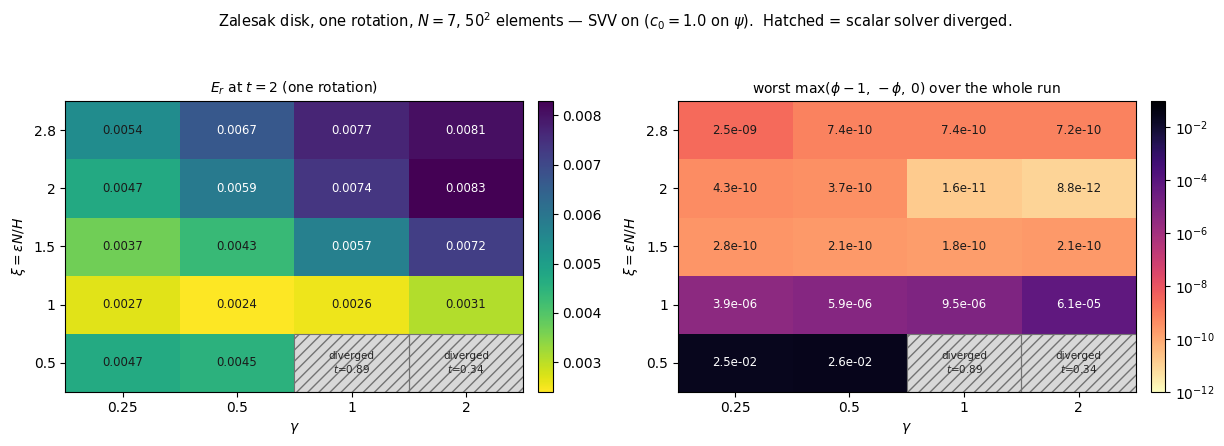

In [7]:
XIS, GAS = [0.5, 1.0, 1.5, 2.0, 2.8], [0.25, 0.5, 1.0, 2.0]
byxg = {(r["xi"], r["gamma"]): r for r in sweep}


def sweep_grid(key):
    """Cell values on the (xi, gamma) grid; NaN where the run diverged, since
    its last frame is not at t = 2 and so is not comparable."""
    a = np.full((len(XIS), len(GAS)), np.nan)
    for i, x in enumerate(XIS):
        for j, g in enumerate(GAS):
            if not byxg[(x, g)]["diverged"]:
                a[i, j] = byxg[(x, g)][key]
    return a


fig, axes = plt.subplots(1, 2, figsize=(12.4, 4.5))
# E_r spans 3.5x -- linear reads better; boundedness spans 9 decades, so log.
panels = [(axes[0], sweep_grid("E_r"), None, plt.cm.viridis_r,
           r"$E_r$ at $t=2$ (one rotation)", "{:.4f}"),
          (axes[1], sweep_grid("worst"), LogNorm(vmin=1e-12, vmax=1e-1),
           plt.cm.magma_r,
           r"worst $\max(\phi-1,\,-\phi,\,0)$ over the whole run", "{:.1e}")]

for ax, A, norm, cmap, title, fmt in panels:
    cmap = cmap.copy(); cmap.set_bad("0.85")
    im = ax.imshow(np.ma.masked_invalid(A), cmap=cmap, norm=norm,
                   origin="lower", aspect="auto")
    for i, x in enumerate(XIS):
        for j, g in enumerate(GAS):
            r = byxg[(x, g)]
            if r["diverged"]:
                ax.add_patch(plt.Rectangle((j - .5, i - .5), 1, 1, fill=False,
                                           hatch="///", edgecolor="0.45", lw=0.8))
                ax.text(j, i, f"diverged\n$t$={r['t_death']:.2f}", ha="center",
                        va="center", fontsize=7.5, color="0.15")
            else:
                ax.text(j, i, fmt.format(A[i, j]), ha="center", va="center",
                        fontsize=8.5,
                        color="white" if im.norm(A[i, j]) > 0.55 else "0.1")
    ax.set_xticks(range(len(GAS))); ax.set_xticklabels([f"{g:g}" for g in GAS])
    ax.set_yticks(range(len(XIS))); ax.set_yticklabels([f"{x:g}" for x in XIS])
    ax.set_xlabel(r"$\gamma$")
    ax.set_ylabel(r"$\xi = \varepsilon N/H$")
    ax.set_title(title, fontsize=10)
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.03)

fig.suptitle("Zalesak disk, one rotation, $N=7$, $50^2$ elements — "
             r"SVV on ($c_0=1.0$ on $\psi$).  Hatched = scalar solver diverged.",
             fontsize=10.5)
fig.tight_layout(rect=[0, 0, 1, 0.94])
os.makedirs("evidence", exist_ok=True)
fig.savefig("evidence/zalesak_xi_gamma_svv_on.png", dpi=160)
print("wrote evidence/zalesak_xi_gamma_svv_on.png")

## Control: is the $\gamma$ trend actually $\Delta t$?

The map above holds $C_{\rm comp}$ fixed, so $\Delta t \propto 1/\gamma$ and its
$\gamma$ axis varies $\Delta t$ by $8\times$ — it does **not** isolate $\gamma$.
This repeats the $\xi=1.5$ row at a **fixed** $\Delta t = 1.2990\times10^{-5}$
(the $\gamma=2$ value, the largest legal for every $\gamma$ in the row). The
$\gamma=2$ point is the *same run* as `output_sw_x15_g200`, reused rather than
repeated.

In [8]:
EPS_CTL = 1.5 * DX_GLL
# (gamma, dir at fixed dt, E_r from the swept-dt map, the dt that map used)
CTL = [(0.25, "output_ctl_g025", 0.00368, 8.8028e-5),
       (0.5,  "output_ctl_g050", 0.00432, 5.1963e-5),
       (1.0,  "output_ctl_g100", 0.00572, 2.5981e-5),
       (2.0,  "output_sw_x15_g200", 0.00719, 1.2990e-5)]   # same cell, reused

print(f"{'gamma':>6}{'E_r fixed dt':>14}{'E_r swept dt':>14}{'ratio':>8}"
      f"{'worst viol':>12}   dt in the map")
ctl_er = []
for g, d, er_map, dt_map in CTL:
    f = sorted(glob.glob(os.path.join(d, "field0.f?????")))
    o = field_c(comm, data=preadnek(f[-1], comm)); phi = o.fields["temp"][0]
    er = nm.E_r(phi, nm.slotted_disk_phase_at(msh7.x, msh7.y, o.t, EPS_CTL),
                coef7, msh7)
    b = read_bnd(os.path.join(d, "bnd.txt"))
    wv = float(max(np.max(b[:, 3] - 1.0), np.max(-b[:, 2]), 0.0))
    tag = "(reused)" if d.startswith("output_sw") else f"{dt_map:.4e}"
    print(f"{g:>6}{er:>14.5f}{er_map:>14.5f}{er/er_map:>8.3f}{wv:>12.2e}   {tag}")
    ctl_er.append(er)

print(f"\nfixed dt : E_r(gamma=2)/E_r(gamma=0.25) = {ctl_er[-1]/ctl_er[0]:.2f}")
print(f"swept dt : same ratio was                 {0.00719/0.00368:.2f}")
print("\ndt moves E_r by <=5% over a 6.8x change, and not monotonically;"
      "\ngamma moves it 2.06x. The gamma effect is real.")

 gamma  E_r fixed dt  E_r swept dt   ratio  worst viol   dt in the map
  0.25       0.00349       0.00368   0.947    2.95e-10   8.8028e-05


   0.5       0.00438       0.00432   1.014    2.20e-10   5.1963e-05


   1.0       0.00572       0.00572   1.001    1.99e-10   2.5981e-05
   2.0       0.00719       0.00719   1.000    2.12e-10   (reused)

fixed dt : E_r(gamma=2)/E_r(gamma=0.25) = 2.06
swept dt : same ratio was                 1.95

dt moves E_r by <=5% over a 6.8x change, and not monotonically;
gamma moves it 2.06x. The gamma effect is real.


## Saini et al. §4.3, recreated — with and without SVV on $\psi$

Their §4.3 Zalesak setup: $H = 1/50$, $N \in \{3,5,7\}$, $\xi = 1$ (their
$\xi = 1/N$, so $\varepsilon = H/N$ and the interface **thins with $N$**),
$N_{svv} = N/2$, $c_0 = 1.0$, ten rotations. Redistancing is off — their §4.3 has
none, because rigid rotation strains nothing.

**What their paper does not show is the same runs with SVV off.** That is the red
family below. Each on/off pair uses an identical $\Delta t$, so `svv_psi.c0` is
the only thing that differs.

Two departures from their setup, both forced:

- Their $\Delta t = 10^{-4}$ violates our compression guard
  ($C_\mathrm{comp} \le 0.05$) by 1.9× at $N{=}5$ and 3.5× at $N{=}7$, so we use
  $\Delta t = 0.045\,h_\mathrm{GLL,min}/(\gamma u_\mathrm{max})$.
- Their §4.3 solves one equation with SVV on the phase field; Neko's CDI solves
  two, and SVV here is a $\psi$-only knob (`svv_phi` is 0 always). So this
  compares the *test problem*, not the method.

In [9]:
H_ELEM = 0.02                       # 50x50 box -> Saini's H = 1/50
S43_NS = (3, 5, 7)

_grid = {}
def s43_grid(N, f0):
    """Each N is a different polynomial order, so a different GLL grid."""
    if N not in _grid:
        m = msh_c(comm, data=preadnek(f0, comm))
        _grid[N] = (m, Coef(m, comm))
    return _grid[N]

def s43_frame(files, t_want, out_value):
    """Frames are written every `out_value`; guess the index and verify its own
    time rather than loading all of them (12 GB at N=7)."""
    i = int(round(t_want / out_value))
    order = ([i] if 0 <= i < len(files) else []) + list(range(len(files)))
    for k in order:
        o = field_c(comm, data=preadnek(files[k], comm))
        if abs(o.t - t_want) < 0.05:
            return o
    return None

def s43_worst(d):
    f = os.path.join(d, "bnd.txt")
    if not os.path.exists(f): return float("nan")
    b = [l.split() for l in open(f) if l.split()[:1] == ["bnd"]]
    if not b: return float("nan")
    lo = np.array([float(x[4]) for x in b]); hi = np.array([float(x[5]) for x in b])
    return float(max(np.max(hi - 1.0), np.max(-lo), 0.0))

def s43_measure(d, N, times, out_value):
    files = sorted(glob.glob(os.path.join(d, "field0.f?????")))
    if not files: return None
    eps = H_ELEM / N
    msh, coef = s43_grid(N, files[0])
    per = nm.contour_length(msh, nm.slotted_disk_phase(msh.x, msh.y, eps), 0.5)
    o0 = field_c(comm, data=preadnek(files[0], comm)); phi0 = o0.fields["temp"][0]
    rec = dict(N=N, eps=eps, worst=s43_worst(d), nframes=len(files))
    for t in times:
        o = s43_frame(files, t, out_value)
        if o is None: continue
        phi = o.fields["temp"][0]
        pe = nm.slotted_disk_phase_at(msh.x, msh.y, o.t, eps)
        rec[f"Er{t:g}"] = nm.E_r(phi, pe, coef, msh)
        rec[f"Ev{t:g}"] = nm.E_v(phi, phi0, pe, coef, msh)
        rec[f"Es{t:g}"] = nm.E_s(phi, pe, coef, msh, per)
    return rec

# --- Stage 1: gamma = 1, ten rotations, SVV on vs off ---------------------
s43 = {}
for N in S43_NS:
    for svv, tag in ((1.0, "svvon"), (0.0, "svvoff")):
        r = s43_measure(f"output_s43_n{N}_{tag}", N, (2.0, 20.0), 0.2)
        if r: s43[(N, svv)] = r

print("Saini 4.3, xi = 1, gamma = 1, ten rotations -- SVV on vs off")
print(f"{'N':>2}{'svv':>5}{'eps':>10} | {'E_r(2)':>9}{'E_r(20)':>9}"
      f"{'E_s(20)':>9}{'|E_v|(20)':>11}{'worst viol':>12}")
for N in S43_NS:
    for svv in (1.0, 0.0):
        r = s43.get((N, svv))
        if not r: continue
        print(f"{N:>2}{svv:>5.0f}{r['eps']:>10.2e} | {r['Er2']:>9.5f}{r['Er20']:>9.5f}"
              f"{r['Es20']:>9.5f}{abs(r['Ev20']):>11.2e}{r['worst']:>12.2e}")
print("\nSVV off/on ratio in E_r at t=20: " + ",  ".join(
    f"N={N}: {s43[(N,0.0)]['Er20']/s43[(N,1.0)]['Er20']:.1f}x" for N in S43_NS
    if (N,0.0) in s43 and (N,1.0) in s43))

# --- Stage 2: gamma families at t = 2, SVV on ----------------------------
# N=7 at gamma 0.5 and 2 are the existing xi=1 sweep cells, reused not rerun.
S43_G = {}
for N in S43_NS:
    for g, tg in ((0.5, "g05"), (1.0, None), (1.5, "g15"), (2.0, "g20")):
        if g == 1.0:
            r = s43.get((N, 1.0)); S43_G[(N, g)] = r; continue
        d = (f"output_sw_x10_g{'050' if g == 0.5 else '200'}"
             if N == 7 and g in (0.5, 2.0) else f"output_s43_n{N}_{tg}")
        r = s43_measure(d, N, (2.0,), 0.1)
        if r: S43_G[(N, g)] = r

print("\ngamma families, E_r at t = 2 (SVV on)")
print(f"{'N':>3}" + "".join(f"{'g='+str(g):>11}" for g in (0.5, 1.0, 1.5, 2.0)))
for N in S43_NS:
    row = f"{N:>3}"
    for g in (0.5, 1.0, 1.5, 2.0):
        r = S43_G.get((N, g))
        row += f"{r['Er2']:>11.5f}" if r and "Er2" in r else f"{'--':>11}"
    print(row)

Saini 4.3, xi = 1, gamma = 1, ten rotations -- SVV on vs off
 N  svv       eps |    E_r(2)  E_r(20)  E_s(20)  |E_v|(20)  worst viol
 3    1  6.67e-03 |   0.03679  0.10117  0.03119   8.01e-10    2.57e-08
 3    0  6.67e-03 |   0.40686  0.93160  0.23265   1.12e-07    1.60e-03
 5    1  4.00e-03 |   0.00737  0.02084  0.00493   1.19e-08    6.36e-06
 5    0  4.00e-03 |   0.35623  0.97472  0.21923   3.12e-06    1.44e-02
 7    1  2.86e-03 |   0.00256  0.00402  0.00089   1.51e-09    9.48e-06
 7    0  2.86e-03 |   0.27457  1.02656  0.23925   3.49e-06    3.05e-02

SVV off/on ratio in E_r at t=20: N=3: 9.2x,  N=5: 46.8x,  N=7: 255.7x



gamma families, E_r at t = 2 (SVV on)
  N      g=0.5      g=1.0      g=1.5      g=2.0
  3    0.03215    0.03679    0.03879    0.03976
  5    0.00642    0.00737    0.00799    0.00839
  7    0.00240    0.00256    0.00284    0.00308


wrote evidence/saini_fig{5,6,7}_*.png


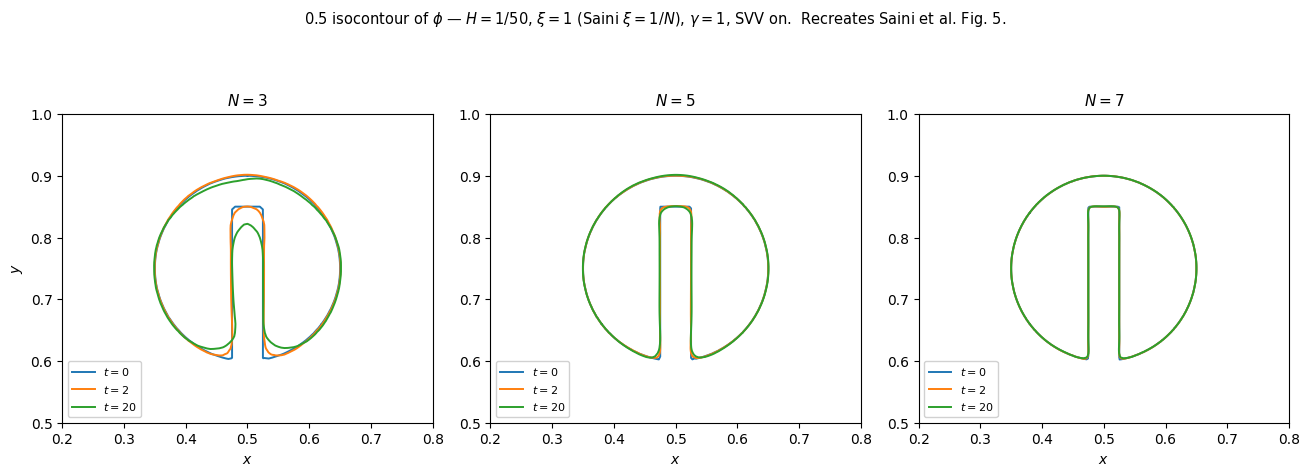

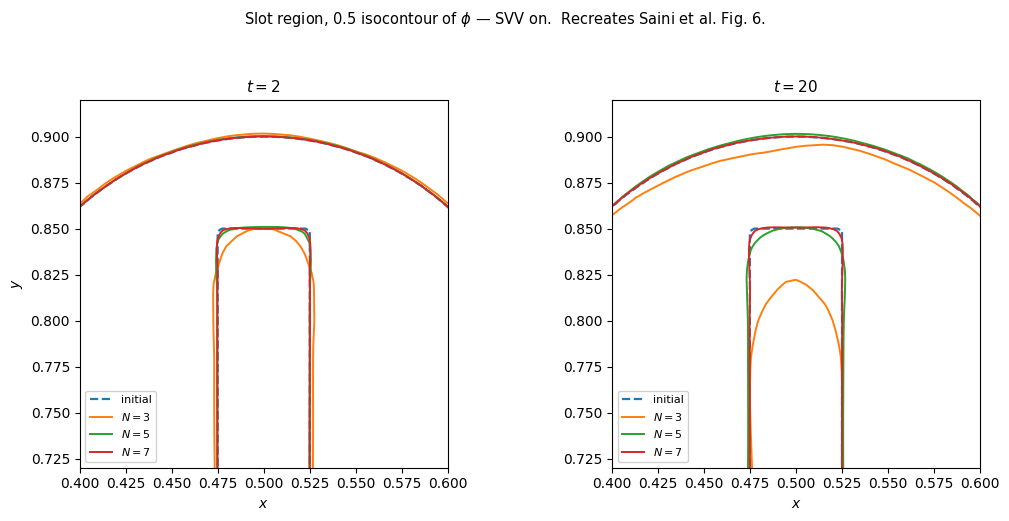

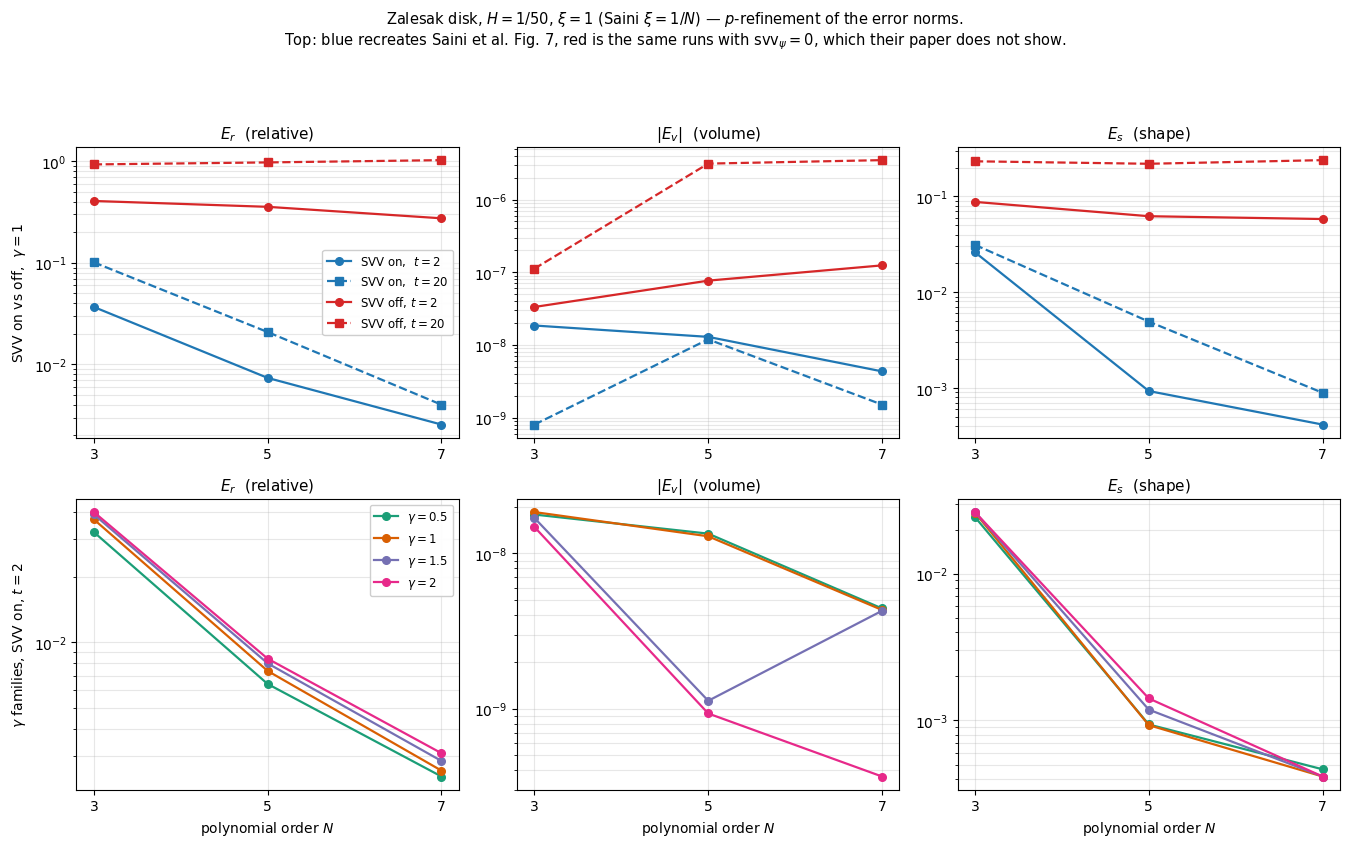

In [10]:
# ---------------- Figs 5 and 6: the 0.5 isocontour ----------------------
def s43_slice(N, tag, t_want, out_value=0.2):
    d = f"output_s43_n{N}_{tag}"
    files = sorted(glob.glob(os.path.join(d, "field0.f?????")))
    if not files: return None, None
    o = s43_frame(files, t_want, out_value)
    if o is None: return None, None
    m, _ = s43_grid(N, files[0]); iz = m.z.shape[1] // 2
    t = mtri.Triangulation(m.x[:, iz, :, :].ravel(), m.y[:, iz, :, :].ravel())
    return t, o.fields["temp"][0][:, iz, :, :].ravel()

fig, axes = plt.subplots(1, 3, figsize=(13.2, 4.7))
for ax, N in zip(axes, S43_NS):
    for t, col, lab in ((0.0, "tab:blue", "$t=0$"), (2.0, "tab:orange", "$t=2$"),
                        (20.0, "tab:green", "$t=20$")):
        tri, v = s43_slice(N, "svvon", t)
        if tri is None: continue
        ax.tricontour(tri, v, levels=[0.5], colors=[col], linewidths=1.4)
        ax.plot([], [], color=col, lw=1.4, label=lab)
    ax.set_aspect("equal"); ax.set_xlim(0.2, 0.8); ax.set_ylim(0.5, 1.0)
    ax.set_title(f"$N={N}$", fontsize=11); ax.set_xlabel("$x$")
    ax.legend(loc="lower left", fontsize=8, framealpha=0.9)
axes[0].set_ylabel("$y$")
fig.suptitle(r"0.5 isocontour of $\phi$ — $H=1/50$, $\xi=1$ (Saini $\xi=1/N$), "
             r"$\gamma=1$, SVV on.  Recreates Saini et al. Fig. 5.", fontsize=10.5)
fig.tight_layout(rect=[0, 0, 1, 0.93])
fig.savefig("evidence/saini_fig5_contours.png", dpi=160)

fig, axes = plt.subplots(1, 2, figsize=(11.0, 5.2))
COL = {3: "tab:orange", 5: "tab:green", 7: "tab:red"}
for ax, t in zip(axes, (2.0, 20.0)):
    tri0, v0 = s43_slice(S43_NS[-1], "svvon", 0.0)
    if tri0 is not None:
        ax.tricontour(tri0, v0, levels=[0.5], colors=["tab:blue"],
                      linewidths=1.6, linestyles="--")
        ax.plot([], [], color="tab:blue", lw=1.6, ls="--", label="initial")
    for N in S43_NS:
        tri, v = s43_slice(N, "svvon", t)
        if tri is None: continue
        ax.tricontour(tri, v, levels=[0.5], colors=[COL[N]], linewidths=1.4)
        ax.plot([], [], color=COL[N], lw=1.4, label=f"$N={N}$")
    ax.set_aspect("equal"); ax.set_xlim(0.40, 0.60); ax.set_ylim(0.72, 0.92)
    ax.set_title(f"$t={t:g}$", fontsize=11); ax.set_xlabel("$x$")
    ax.legend(loc="lower left", fontsize=8, framealpha=0.9)
axes[0].set_ylabel("$y$")
fig.suptitle(r"Slot region, 0.5 isocontour of $\phi$ — SVV on.  "
             r"Recreates Saini et al. Fig. 6.", fontsize=10.5)
fig.tight_layout(rect=[0, 0, 1, 0.93])
fig.savefig("evidence/saini_fig6_slot_zoom.png", dpi=160)

# ---------------- Fig 7: p-refinement of the norms ----------------------
# Top row is Saini's Fig. 7 plus the SVV-off family they do not show;
# bottom row is the gamma dependence at t = 2.
fig, axes = plt.subplots(2, 3, figsize=(13.6, 8.6))
PANEL = [("Er", r"$E_r$  (relative)"), ("Ev", r"$|E_v|$  (volume)"),
         ("Es", r"$E_s$  (shape)")]
STYLE = {(1.0, 2.0):  dict(color="tab:blue", marker="o", ls="-",  label="SVV on,  $t=2$"),
         (1.0, 20.0): dict(color="tab:blue", marker="s", ls="--", label="SVV on,  $t=20$"),
         (0.0, 2.0):  dict(color="tab:red",  marker="o", ls="-",  label="SVV off, $t=2$"),
         (0.0, 20.0): dict(color="tab:red",  marker="s", ls="--", label="SVV off, $t=20$")}
for ax, (key, title) in zip(axes[0], PANEL):
    for (svv, t), st in STYLE.items():
        y = [abs(s43[(N, svv)][f"{key}{t:g}"]) if (N, svv) in s43
             and f"{key}{t:g}" in s43[(N, svv)] else np.nan for N in S43_NS]
        if all(np.isnan(v) for v in y): continue
        ax.plot(S43_NS, y, **st, markersize=5.5, lw=1.6)
    ax.set_yscale("log"); ax.set_xticks(S43_NS); ax.grid(alpha=0.3, which="both")
    ax.set_title(title, fontsize=11)
axes[0][0].legend(fontsize=8.5, framealpha=0.95)
axes[0][0].set_ylabel("SVV on vs off,  $\\gamma=1$", fontsize=10)

GC = {0.5: "#1b9e77", 1.0: "#d95f02", 1.5: "#7570b3", 2.0: "#e7298a"}
for ax, (key, title) in zip(axes[1], PANEL):
    for g, col in GC.items():
        y = [abs(S43_G[(N, g)][f"{key}2"]) if S43_G.get((N, g))
             and f"{key}2" in S43_G[(N, g)] else np.nan for N in S43_NS]
        if all(np.isnan(v) for v in y): continue
        ax.plot(S43_NS, y, color=col, marker="o", ls="-", lw=1.6,
                markersize=5.5, label=f"$\\gamma={g:g}$")
    ax.set_yscale("log"); ax.set_xticks(S43_NS); ax.grid(alpha=0.3, which="both")
    ax.set_xlabel("polynomial order $N$"); ax.set_title(title, fontsize=11)
axes[1][0].legend(fontsize=8.5, framealpha=0.95)
axes[1][0].set_ylabel("$\\gamma$ families, SVV on, $t=2$", fontsize=10)

fig.suptitle("Zalesak disk, $H=1/50$, $\\xi=1$ (Saini $\\xi=1/N$) — "
             "$p$-refinement of the error norms.\n"
             "Top: blue recreates Saini et al. Fig. 7, red is the same runs with "
             "$\\mathrm{svv}_\\psi=0$, which their paper does not show.",
             fontsize=10.5)
fig.tight_layout(rect=[0, 0, 1, 0.93])
fig.savefig("evidence/saini_fig7_norms.png", dpi=160)
print("wrote evidence/saini_fig{5,6,7}_*.png")